In [64]:
import pandas as pd
import matplotlib.pyplot as plt

## Read and transform data

In [65]:
spy_df = pd.read_pickle('spy_data.pkl')
gld_df = pd.read_pickle('gld_data.pkl')

spy_df['timestamp'] = pd.to_datetime(spy_df['timestamp'], unit='ms')
spy_df.set_index('timestamp', inplace=True)

gld_df['timestamp'] = pd.to_datetime(gld_df['timestamp'], unit='ms')
gld_df.set_index('timestamp', inplace=True)

### Normalize the data wrt $100

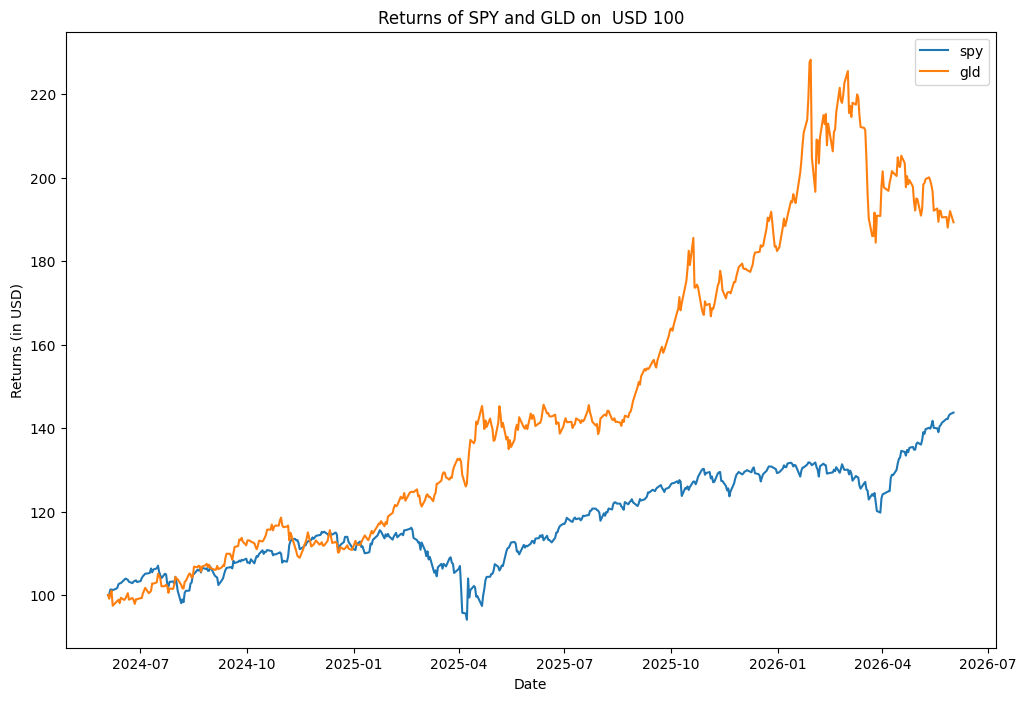

In [66]:
spy_returns = spy_df['close'] / spy_df['close'].iloc[0] * 100
gld_returns = gld_df['close'] / gld_df['close'].iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(spy_df.index, spy_returns)
ax.plot(gld_df.index, gld_returns)
ax.set_ylabel('Returns (in USD)')
ax.set_xlabel('Date')
plt.title('Returns of SPY and GLD on  USD 100')
plt.legend(['spy', 'gld'])
plt.show()

### Computing Correlations

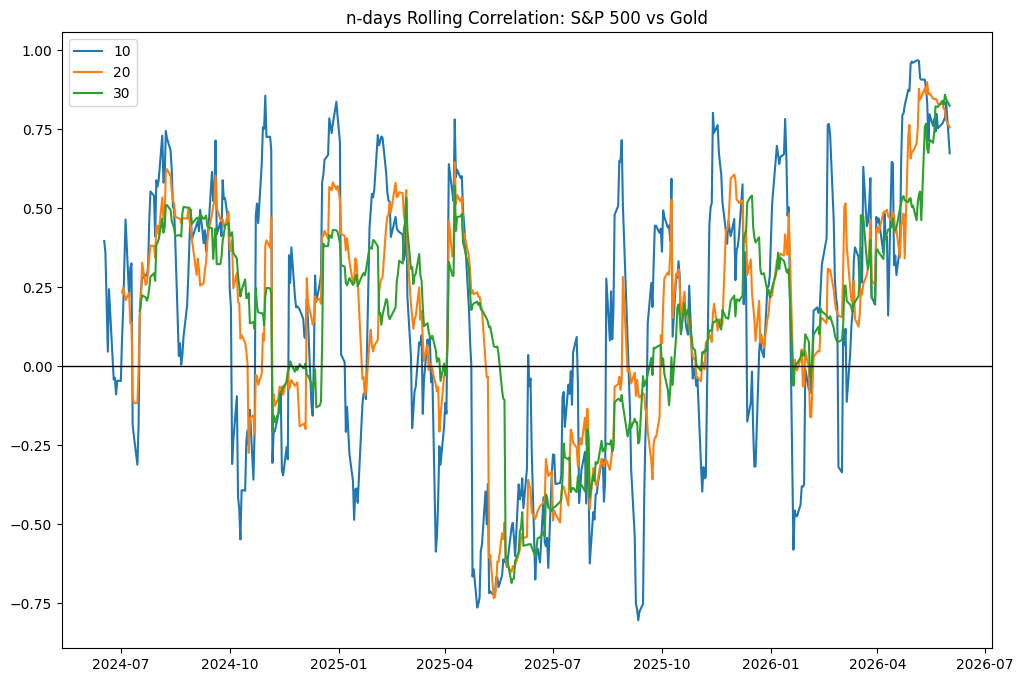

In [67]:
data = pd.DataFrame({'SPY': spy_returns, 'GLD': gld_returns})
returns = data.pct_change().dropna()

rolling_correlations = {}

rolling_window = 10
rolling_correlations[rolling_window] = returns['SPY'].rolling(rolling_window).corr(returns['GLD'])
rolling_correlations[rolling_window] = rolling_correlations[rolling_window].dropna()

rolling_window = 20
rolling_correlations[rolling_window] = returns['SPY'].rolling(rolling_window).corr(returns['GLD'])
rolling_correlations[rolling_window] = rolling_correlations[rolling_window].dropna()

rolling_window = 30
rolling_correlations[rolling_window] = returns['SPY'].rolling(rolling_window).corr(returns['GLD'])
rolling_correlations[rolling_window] = rolling_correlations[rolling_window].dropna()

fig, ax = plt.subplots(figsize=(12, 8))
for rolling_window, rolling_correlation in rolling_correlations.items():
    ax.plot(rolling_correlation.index, rolling_correlation, label=rolling_window)
ax.axhline(0, color='k', linewidth=1)
plt.title('n-days Rolling Correlation: S&P 500 vs Gold')
plt.legend()
plt.show()

## Z-Score

In [68]:
beta = data['GLD'].pct_change().cov(data['SPY'].pct_change()) / data['SPY'].pct_change().var()
spread = data['GLD'] - beta * data['SPY']
z_score = (spread - spread.mean()) / spread.std()

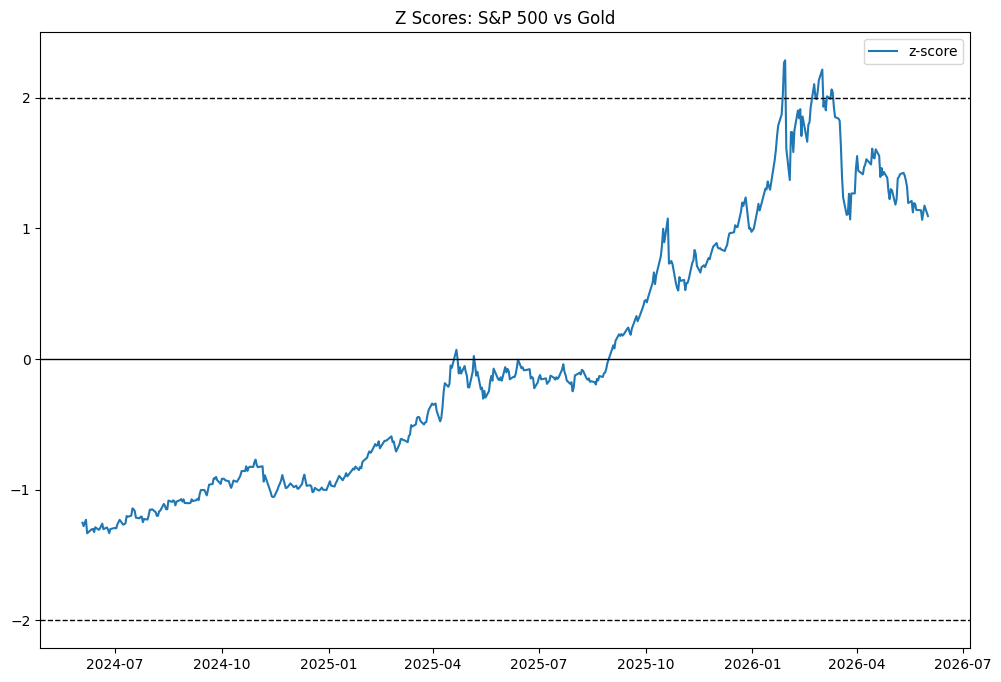

In [69]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(z_score, label='z-score')
ax.axhline(0, color='k', linewidth=1)
ax.axhline(-2, color='k', linewidth=1, linestyle='--')
ax.axhline(2, color='k', linewidth=1, linestyle='--')
plt.title('Z Scores: S&P 500 vs Gold')
plt.legend()
plt.show()
ax.legend()
plt.show()

## Drawdown

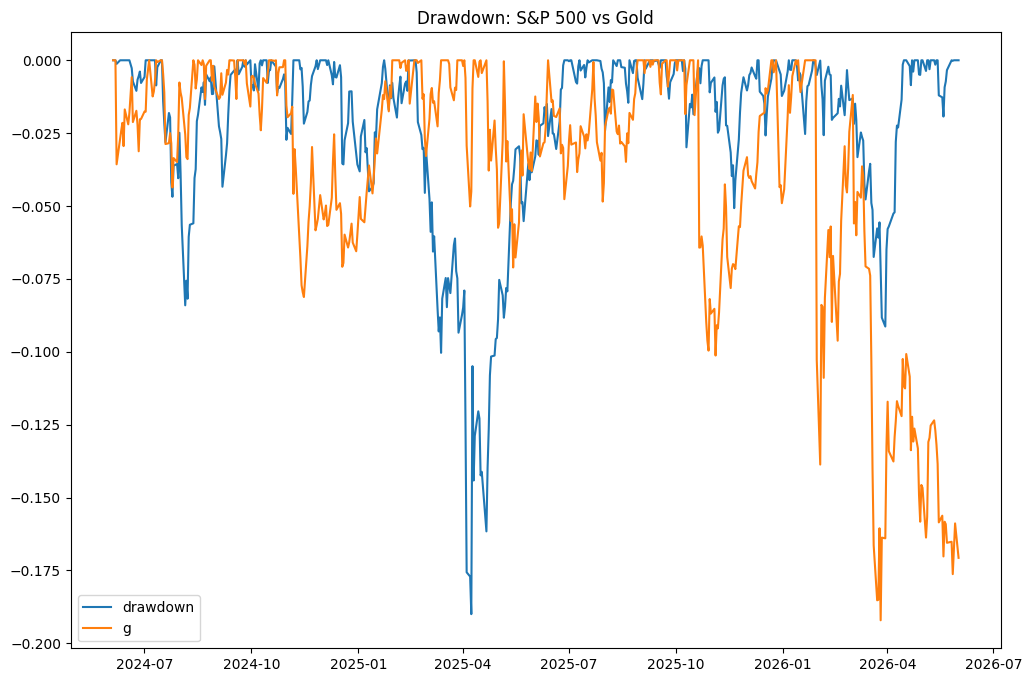

In [70]:
cum = (1 + returns).cumprod()
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(drawdown, label=['drawdown', 'g'])
plt.legend()
plt.title('Drawdown: S&P 500 vs Gold')
plt.show()

### All plots combined

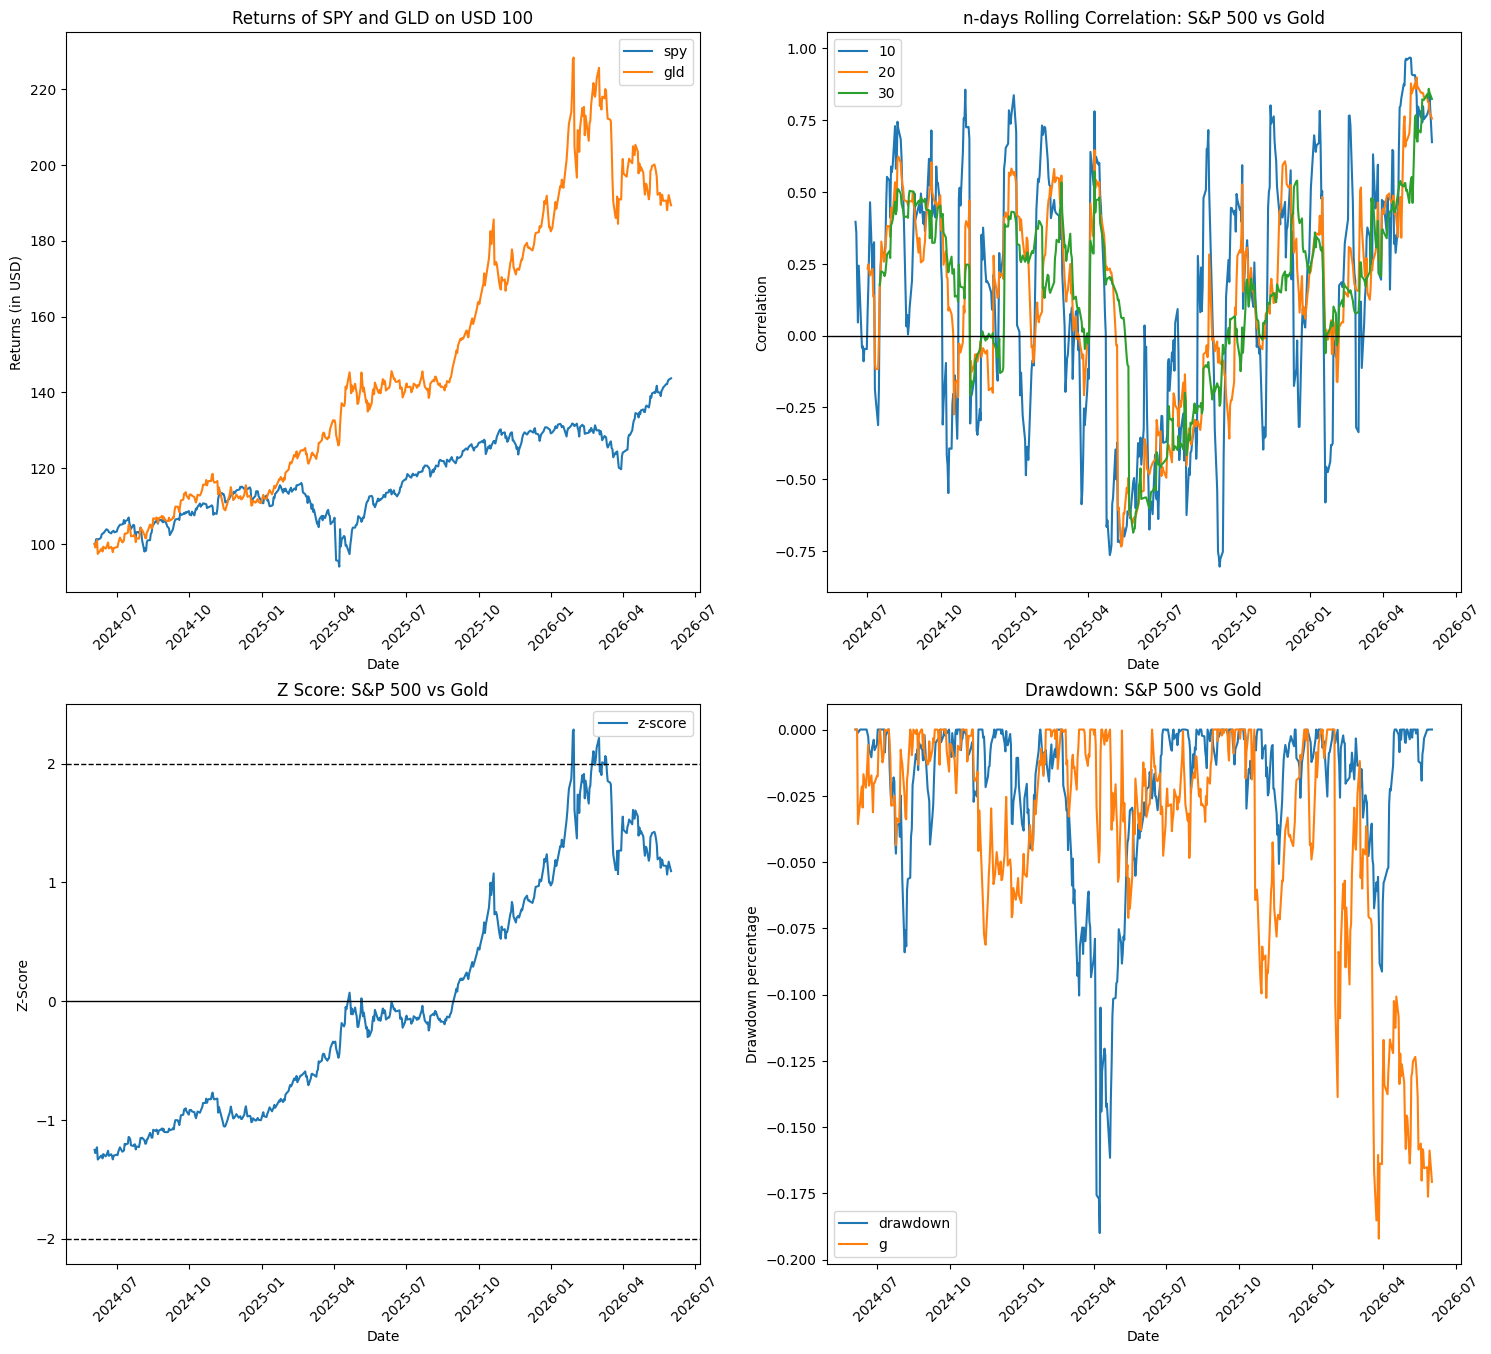

In [72]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(18, 16))
ax1.plot(spy_df.index, spy_returns)
ax1.plot(gld_df.index, gld_returns)
ax1.set_ylabel('Returns (in USD)')
ax1.set_xlabel('Date')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Returns of SPY and GLD on USD 100')
ax1.legend(['spy', 'gld'])

for rolling_window, rolling_correlation in rolling_correlations.items():
    ax2.plot(rolling_correlation.index, rolling_correlation, label=rolling_window)
ax2.axhline(0, color='k', linewidth=1)
ax2.set_ylabel('Correlation')
ax2.set_xlabel('Date')
ax2.tick_params(axis='x', rotation=45)
ax2.set_title('n-days Rolling Correlation: S&P 500 vs Gold')
ax2.legend()

ax3.plot(z_score, label='z-score')
ax3.axhline(0, color='k', linewidth=1)
ax3.axhline(-2, color='k', linewidth=1, linestyle='--')
ax3.axhline(2, color='k', linewidth=1, linestyle='--')
ax3.set_ylabel('Z-Score')
ax3.set_xlabel('Date')
ax3.set_title('Z Score: S&P 500 vs Gold')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()

ax4.plot(drawdown, label=['drawdown', 'g'])
ax4.legend()
ax4.set_ylabel('Drawdown percentage')
ax4.set_xlabel('Date')
ax4.set_title('Drawdown: S&P 500 vs Gold')
ax4.tick_params(axis='x', rotation=45)
ax4.legend()

plt.show()